In [2]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from pathlib import Path
from statsmodels.tsa.stattools import adfuller
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
CHART_DIRECTORY = Path("../outputs/figures")
CHART_DIRECTORY.mkdir(parents=True, exist_ok=True)

def save_chart(fig, filename):
    output_path = CHART_DIRECTORY / f"{filename}.png"

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved: {output_path}")

In [4]:
PROCESSED_DATA_PATH = Path(
    "../data/processed/daily_terminal_volume.csv"
)

df_complete = pd.read_csv(
    PROCESSED_DATA_PATH,
    parse_dates=["Date"]
)

df_complete = df_complete.sort_values(
    ["location", "Date"]
).reset_index(drop=True)

df_complete.head()

,Date,location,actual,was_missing,was_recorded_zero,day_of_week,day_of_week_num,is_weekend,holiday_name,is_holiday,is_weekend_or_holiday,day_type,model_volume,assumed_non_operating,operating_status,iso_year,iso_week,imputation_method,year,is_operating
0,2021-01-01,1,NaN,True,False,Friday,4,False,New Year's Day,True,True,Weekday holiday,0.0,True,Assumed non-operating,2020,53,Weekday holiday set to zero,2021,0
1,2021-01-02,1,NaN,True,False,Saturday,5,True,NaN,False,True,Weekend,0.0,True,Assumed non-operating,2020,53,Missing weekend set to zero,2021,0
2,2021-01-03,1,0.0,False,True,Sunday,6,True,NaN,False,True,Weekend,0.0,False,Confirmed non-operating,2020,53,NaN,2021,0
3,2021-01-04,1,4541.0,False,False,Monday,0,False,NaN,False,False,Regular weekday,4541.0,False,Operating,2021,1,NaN,2021,1
4,2021-01-05,1,4485.0,False,False,Tuesday,1,False,NaN,False,False,Regular weekday,4485.0,False,Operating,2021,1,NaN,2021,1


In [5]:
# Dropping some redundant columns

columns_to_remove = [
    "was_missing",
    "was_recorded_zero",
    "holiday_name",
    "is_weekend_or_holiday",
    "operating_status"
]

df_complete = df_complete.drop(
    columns=columns_to_remove,
    errors="ignore"
)

In [6]:
df_complete = df_complete.drop(
    columns=["iso_year", "iso_week"],
    errors="ignore"
)

In [7]:
df_complete.to_csv(
    PROCESSED_DATA_PATH,
    index=False,
    date_format="%Y-%m-%d"
)

ACF and PACF analysis

ACF and PACF are examined using training data through March 7, 2026. The holdout period is excluded to prevent model-selection leakage.

The analysis is used to identify weekly seasonality and candidate autoregressive, moving-average, and lag-feature structures.

In [8]:
#creating timestamps for training and testing split
TRAIN_END = pd.Timestamp("2026-03-07")
TEST_START = pd.Timestamp("2026-03-08")
TEST_END = pd.Timestamp("2026-04-04")

In [9]:
train_df = (
    df_complete.loc[
        df_complete["Date"].le(TRAIN_END)
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    df_complete.loc[
        df_complete["Date"].between(
            TEST_START,
            TEST_END
        )
    ]
    .copy()
    .reset_index(drop=True)
)

In [10]:
#validating the split
print(
    f"Training period: "
    f"{train_df['Date'].min():%Y-%m-%d} to "
    f"{train_df['Date'].max():%Y-%m-%d}"
)

print(
    f"Testing period: "
    f"{test_df['Date'].min():%Y-%m-%d} to "
    f"{test_df['Date'].max():%Y-%m-%d}"
)

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows: {len(test_df):,}")
print(f"Testing days: {test_df['Date'].nunique()}")

Training period: 2021-01-01 to 2026-03-07
Testing period: 2026-03-08 to 2026-04-04
Training rows: 15,136
Testing rows: 224
Testing days: 28


In [11]:
for data in [train_df, test_df]:
    data["holiday_flag"] = (
        data["is_holiday"]
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1"])
        .astype("int8")
    )

In [12]:
train_df.groupby(
    ["location", "holiday_flag"]
).size()

location  holiday_flag
1         0               1862
          1                 30
2         0               1862
          1                 30
3         0               1862
          1                 30
4         0               1862
          1                 30
5         0               1862
          1                 30
6         0               1862
          1                 30
7         0               1862
          1                 30
8         0               1862
          1                 30
dtype: int64

In [13]:
split_summary = (
    test_df.groupby("location")
    .agg(
        test_days=("Date", "size"),
        observed_actuals=("actual", "count"),
        imputed_test_values=(
            "actual",
            lambda x: x.isna().sum()
        )
    )
    .reset_index()
)

split_summary

,location,test_days,observed_actuals,imputed_test_values
0,1,28,19,9
1,2,28,19,9
2,3,28,19,9
3,4,28,24,4
4,5,28,20,8
5,6,28,28,0
6,7,28,27,1
7,8,28,27,1


In [14]:
#running acf
acf_check = (
    train_df.groupby("location")
    .agg(
        observations=("model_volume", "size"),
        missing_values=("model_volume", lambda x: x.isna().sum()),
        start_date=("Date", "min"),
        end_date=("Date", "max")
    )
    .reset_index()
)

acf_check

,location,observations,missing_values,start_date,end_date
0,1,1892,0,2021-01-01,2026-03-07
1,2,1892,0,2021-01-01,2026-03-07
2,3,1892,0,2021-01-01,2026-03-07
3,4,1892,0,2021-01-01,2026-03-07
4,5,1892,0,2021-01-01,2026-03-07
5,6,1892,0,2021-01-01,2026-03-07
6,7,1892,0,2021-01-01,2026-03-07
7,8,1892,0,2021-01-01,2026-03-07


In [15]:
#defining the plotting function for acf and pcf
def plot_raw_acf_pacf(location, lags=60):
    terminal_series = (
        train_df.loc[
            train_df["location"].eq(location)
        ]
        .sort_values("Date")
        .set_index("Date")["model_volume"]
        .astype(float)
    )

    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5)
    )

    plot_acf(
        terminal_series,
        lags=lags,
        ax=axes[0],
        zero=False
    )

    plot_pacf(
        terminal_series,
        lags=lags,
        method="ywm",
        ax=axes[1],
        zero=False
    )

    axes[0].set_title(
        f"Location {location}: Raw ACF"
    )
    axes[1].set_title(
        f"Location {location}: Raw PACF"
    )

    for ax in axes:
        ax.set_xticks(range(0, lags + 1, 7))
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

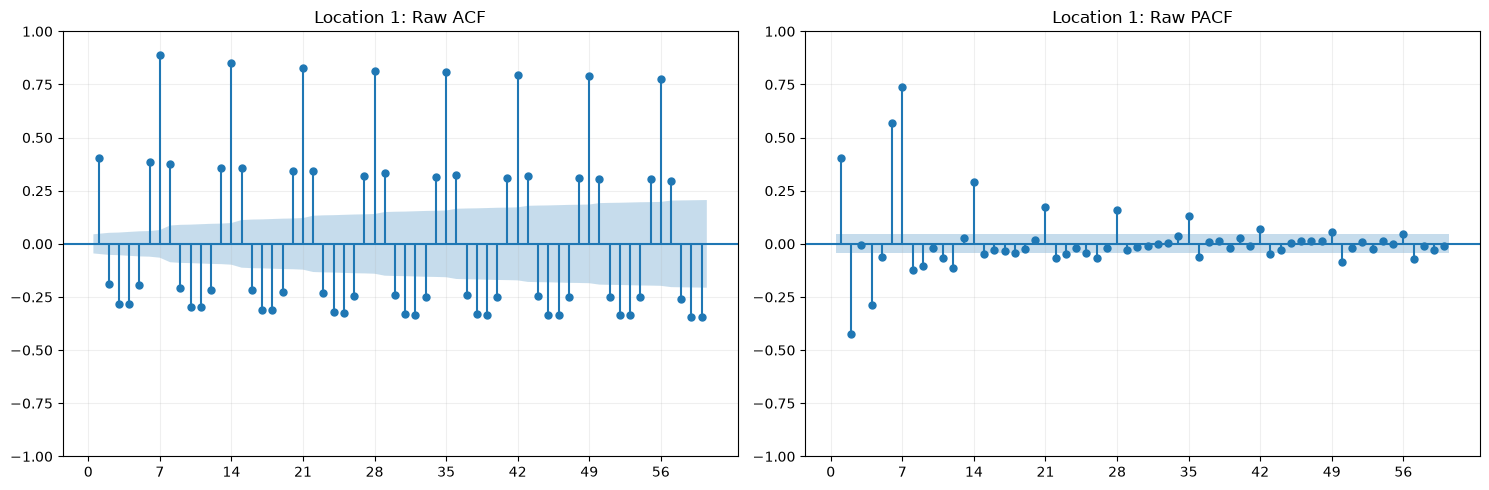

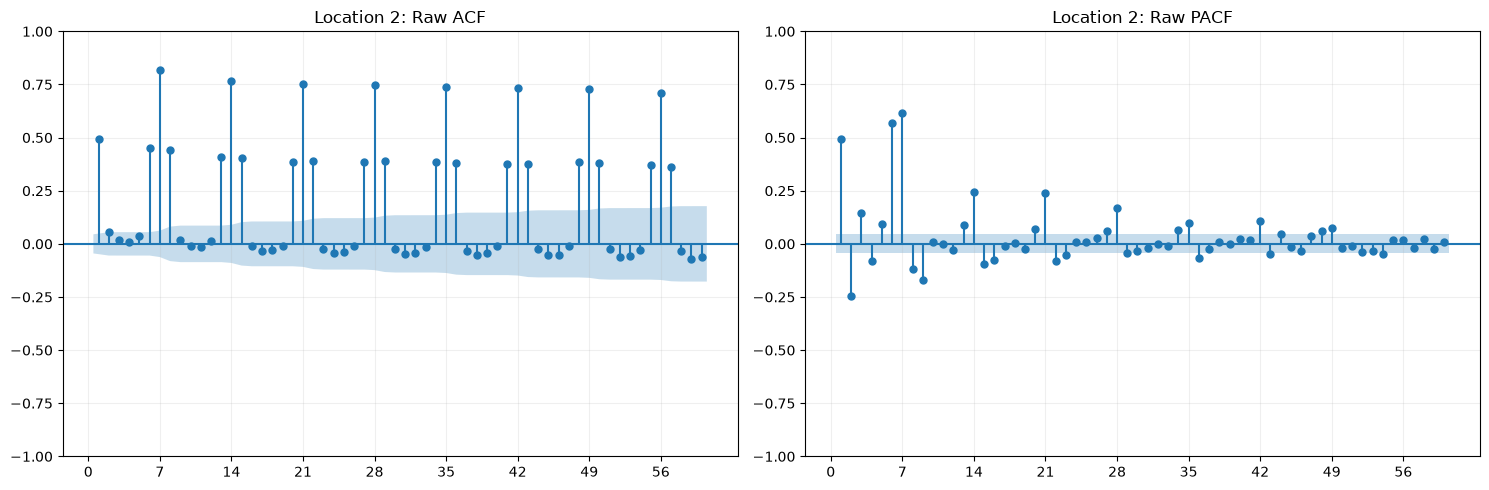

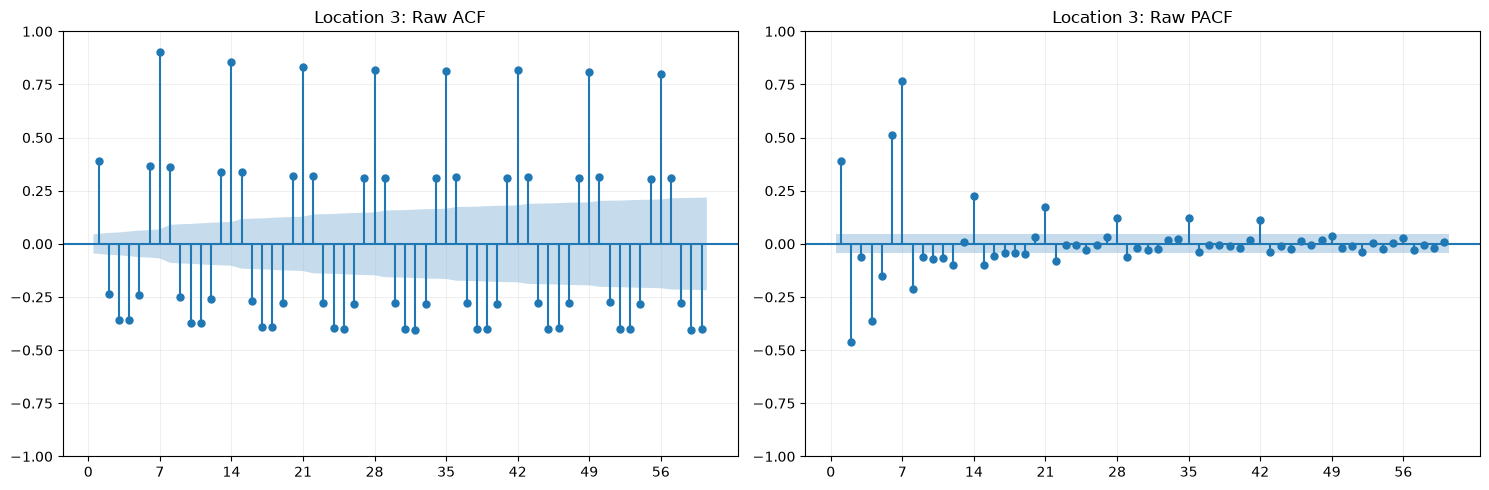

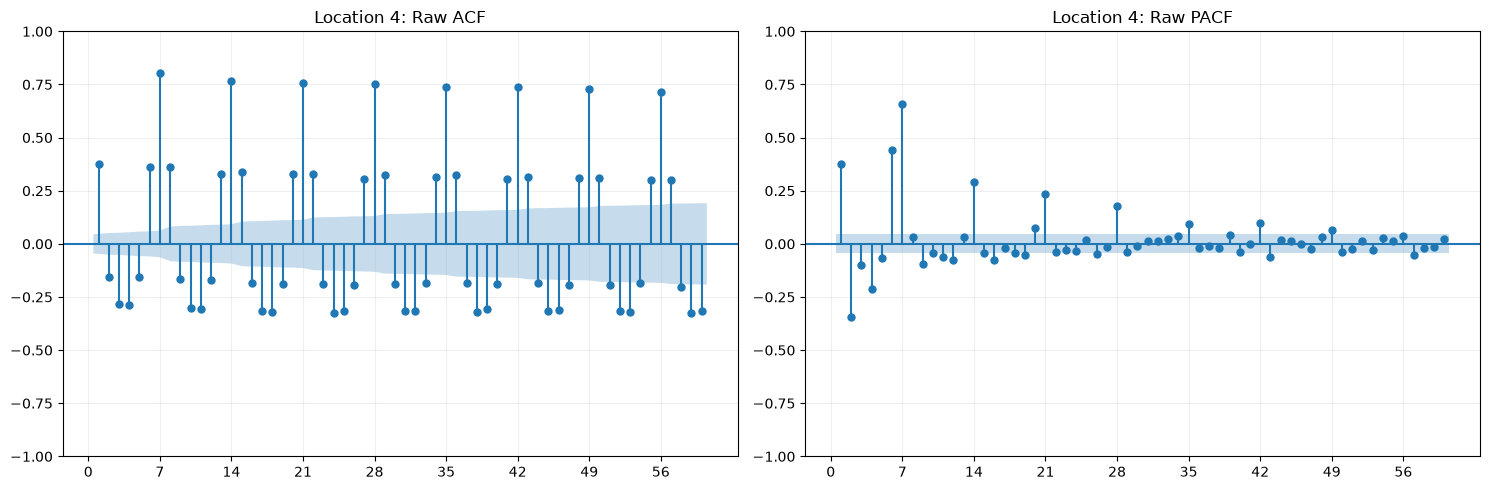

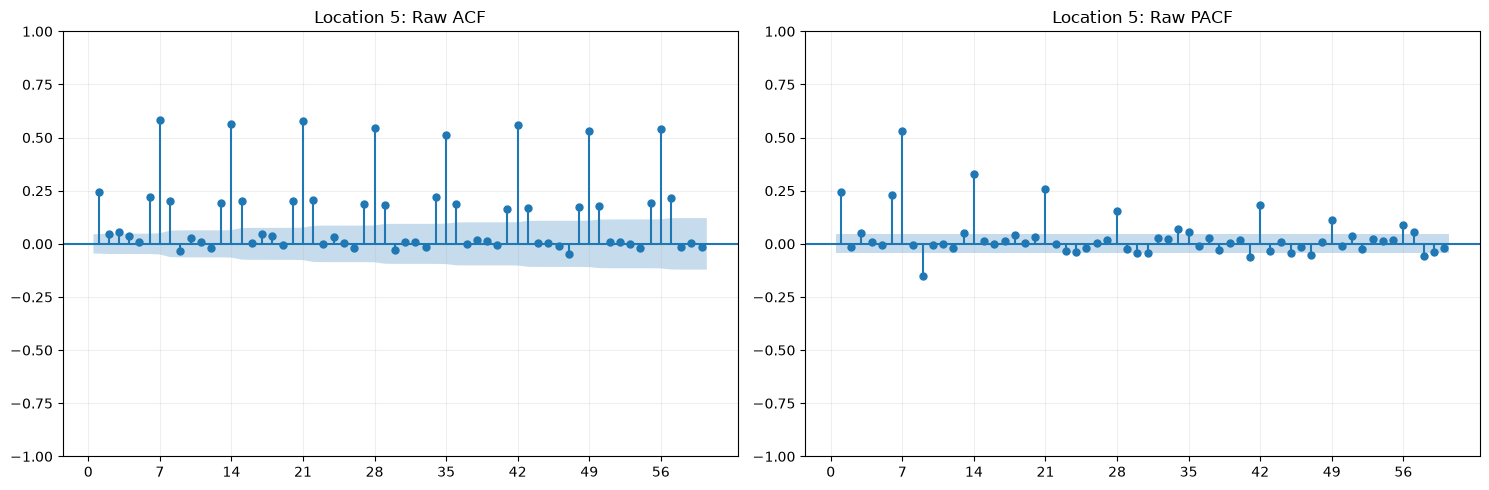

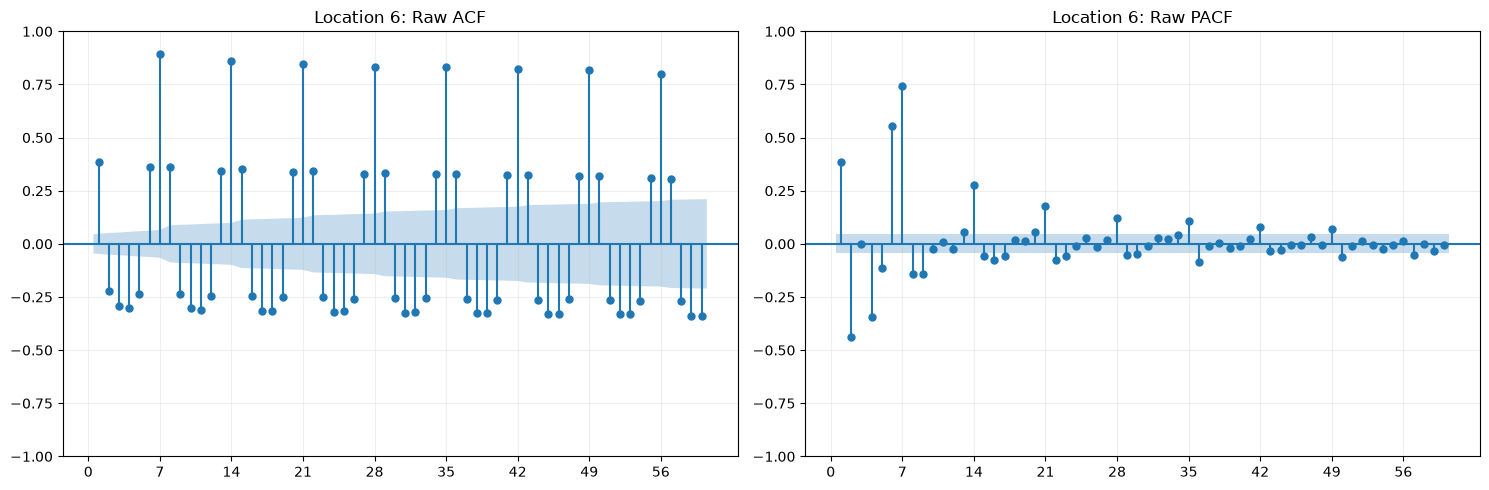

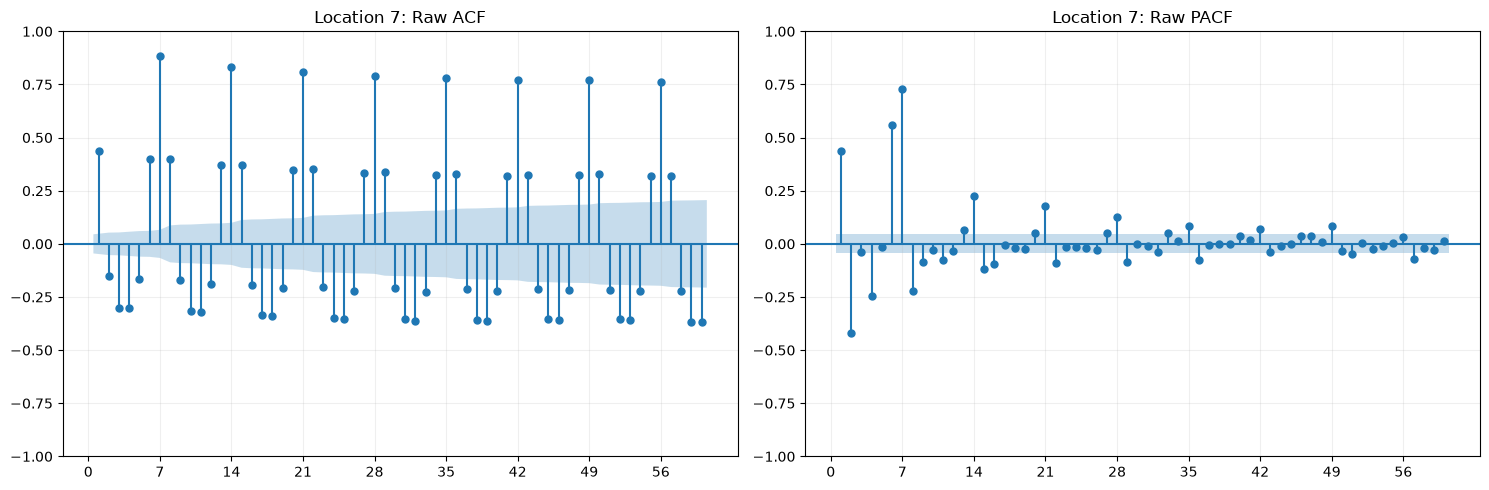

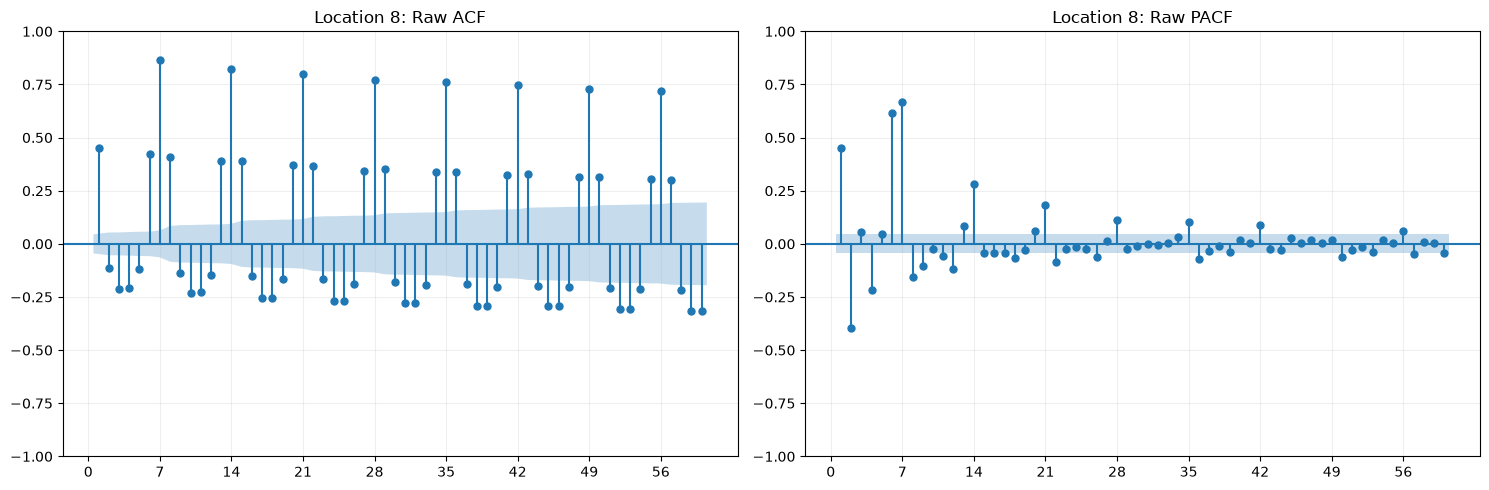

In [16]:
#plotting for each terminal
for location in sorted(train_df["location"].unique()):
    plot_raw_acf_pacf(location)

The data shows strong weekly seasonality. There are significant spikes at 7,14,21,28 day intervals. 7 day differencing will be applied to the data to remove the weekly seasonality. 

In [17]:
#Plotting the asf and pacf with differencing
def plot_differenced_acf_pacf(location, lags=60):
    terminal_series = (
        train_df.loc[
            train_df["location"].eq(location)
        ]
        .sort_values("Date")
        .set_index("Date")["model_volume"]
        .astype(float)
    )

    seasonal_difference = terminal_series.diff(7).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    plot_acf(
        seasonal_difference,
        lags=lags,
        ax=axes[0],
        zero=False
    )

    plot_pacf(
        seasonal_difference,
        lags=lags,
        method="ywm",
        ax=axes[1],
        zero=False
    )

    axes[0].set_title(
        f"Location {location}: ACF After 7-Day Differencing"
    )
    axes[1].set_title(
        f"Location {location}: PACF After 7-Day Differencing"
    )

    for ax in axes:
        ax.set_xticks(range(0, lags + 1, 7))
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

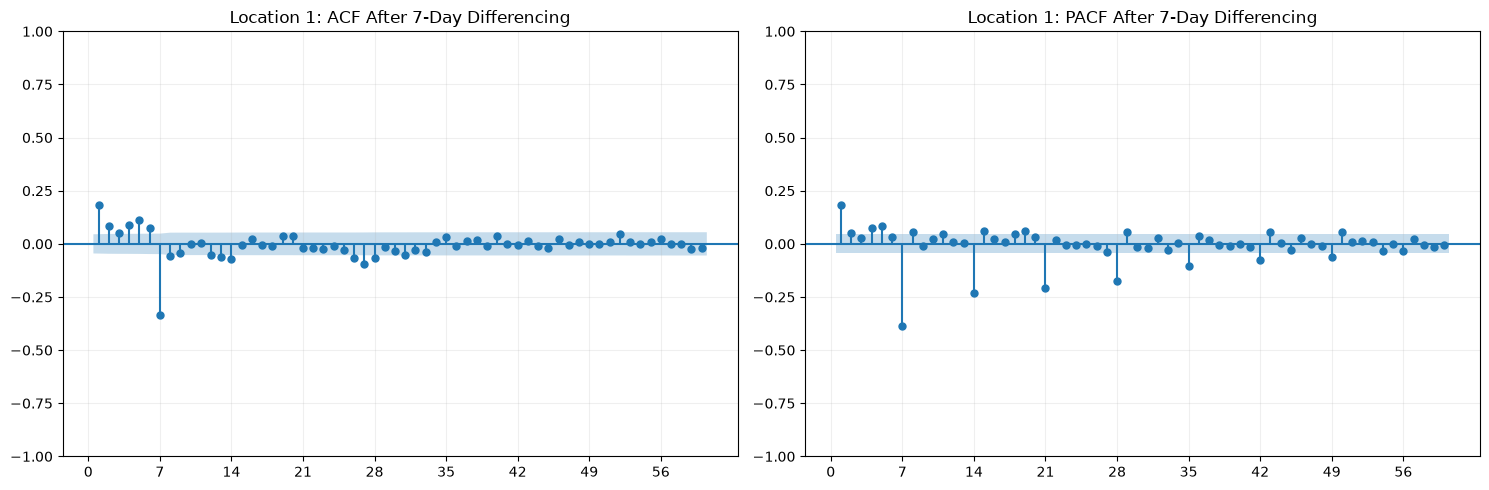

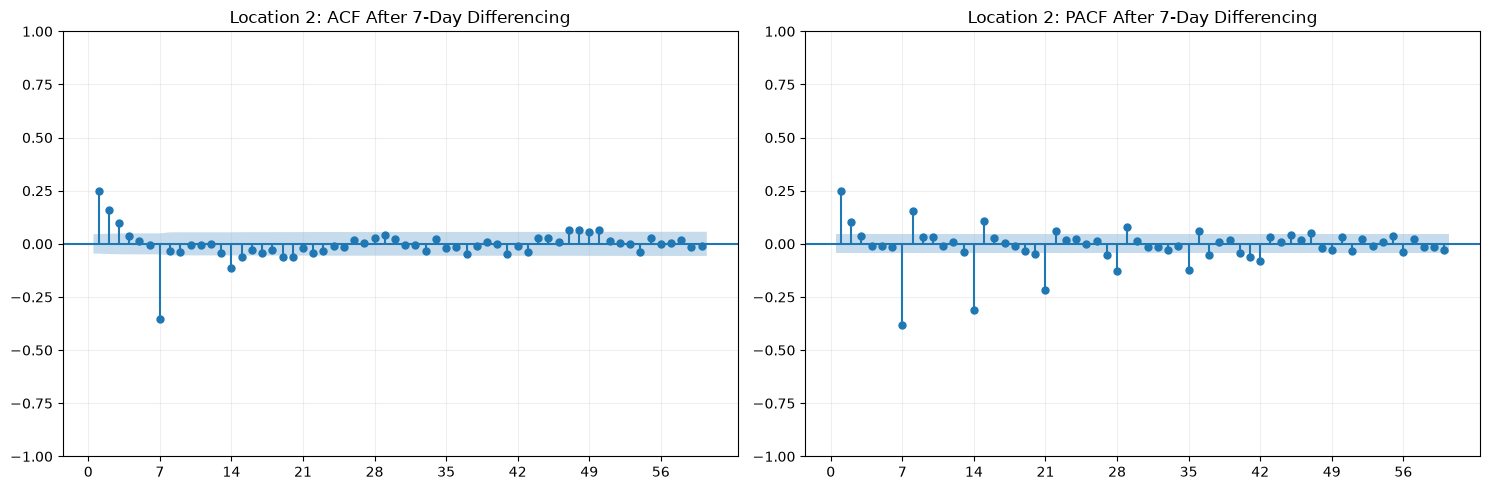

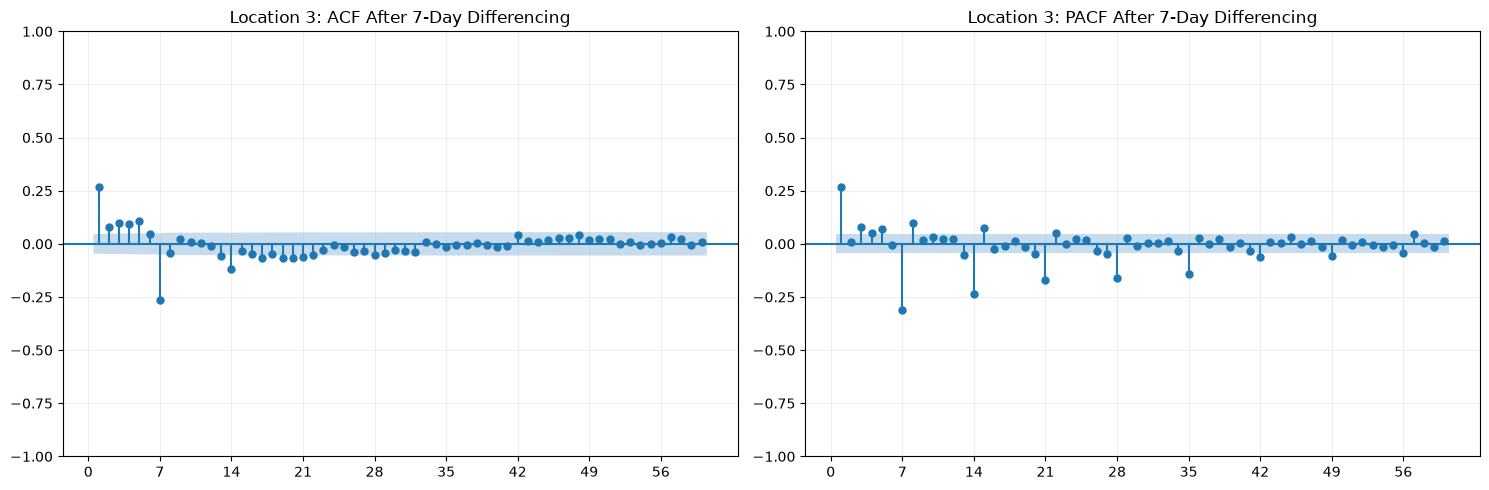

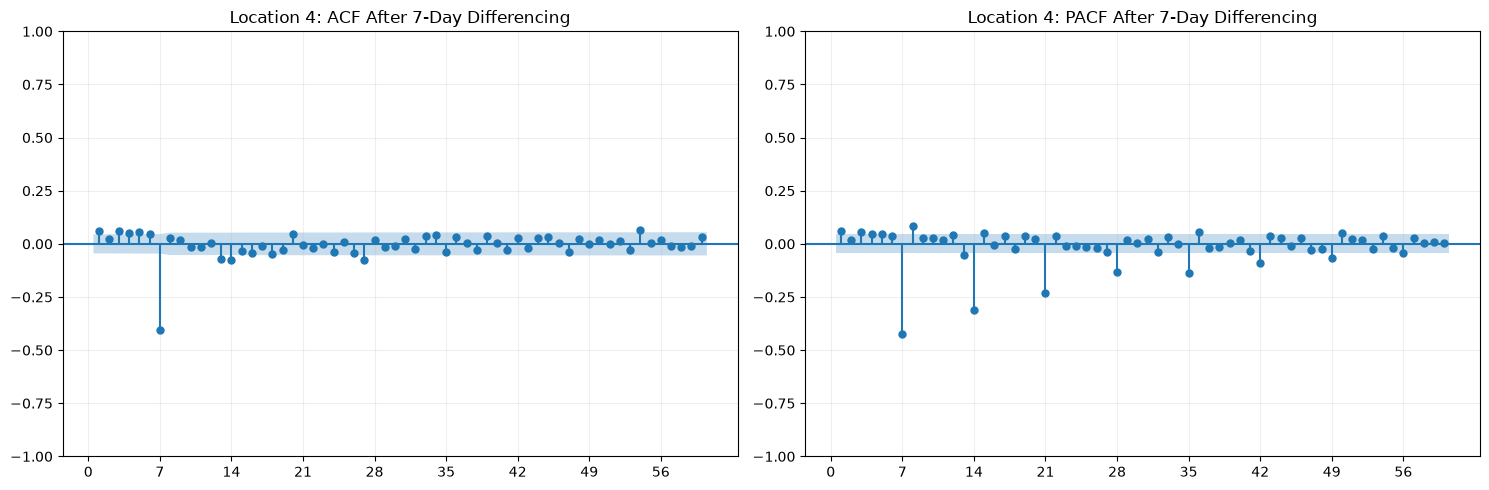

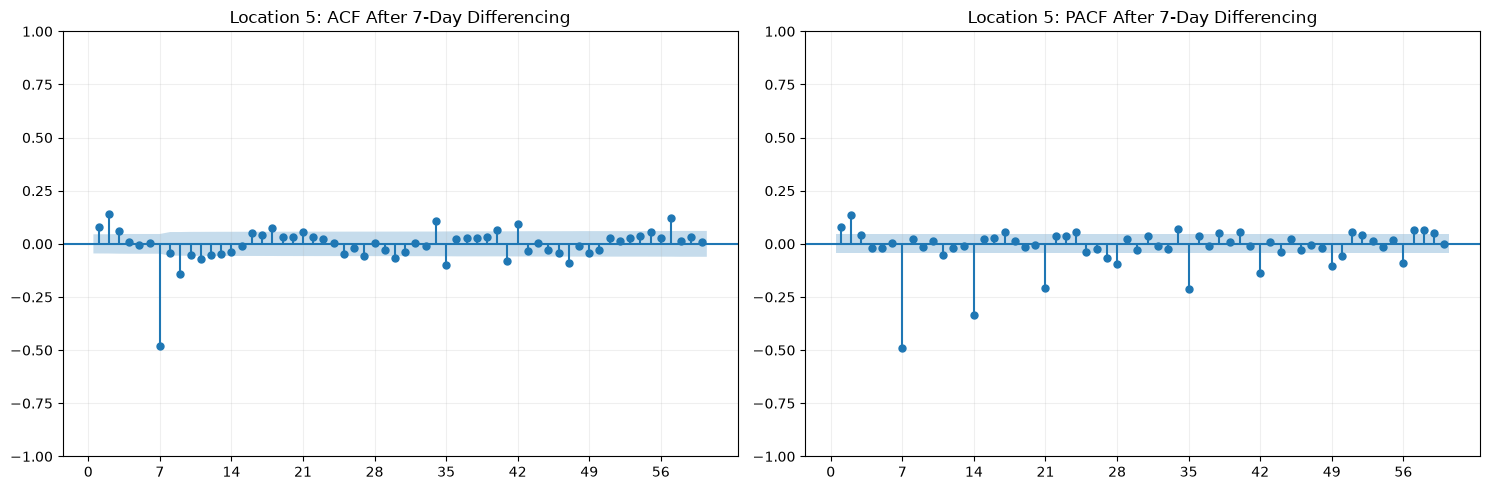

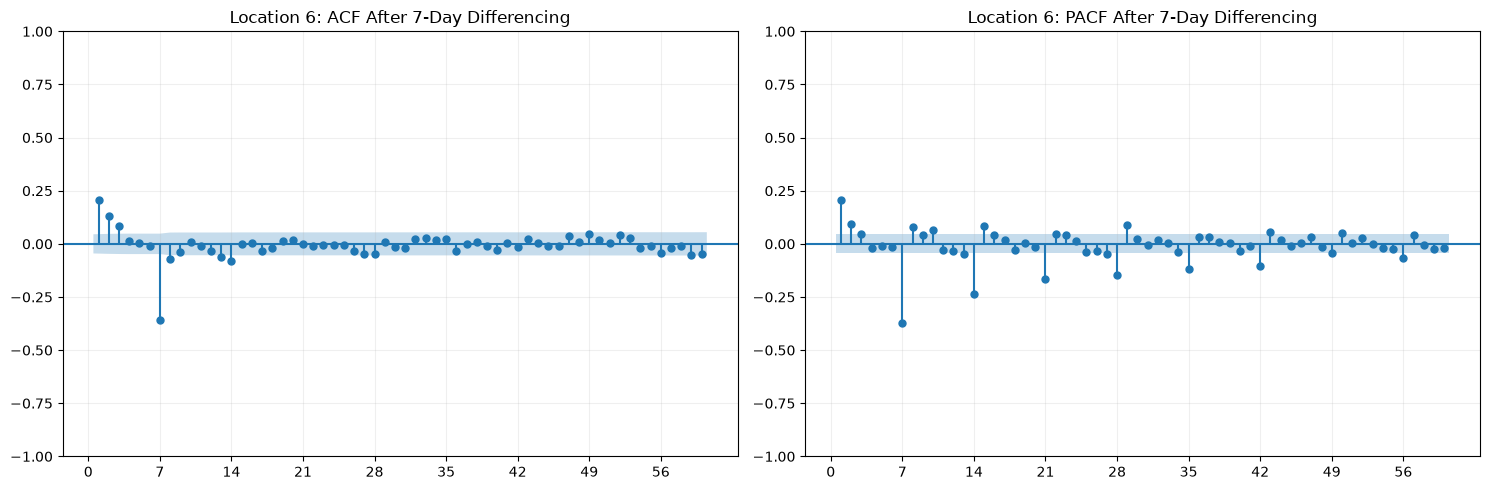

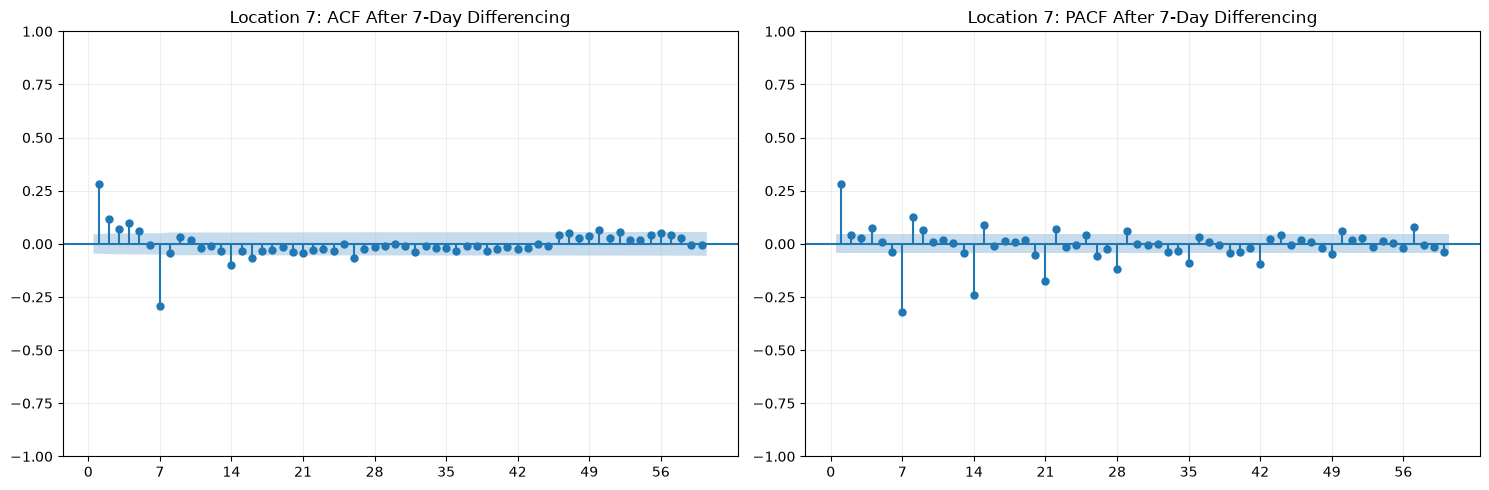

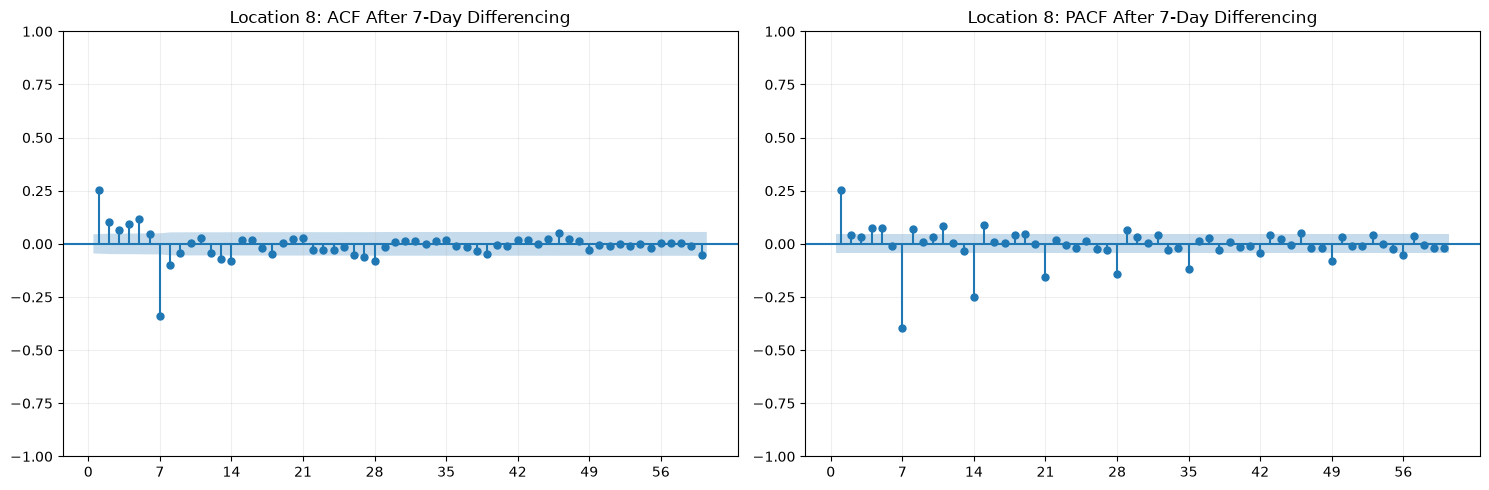

In [18]:
for location in sorted(train_df["location"].unique()):
    plot_differenced_acf_pacf(location)

In [19]:
#performing ADF test on raw and differenced data
adf_results = []

for location, location_data in train_df.groupby("location"):
    raw_series = (
        location_data.sort_values("Date")["model_volume"]
        .astype(float)
    )

    seasonal_difference = raw_series.diff(7).dropna()

    for transformation, series in [
        ("Raw", raw_series),
        ("7-day seasonal difference", seasonal_difference)
    ]:
        result = adfuller(
            series,
            autolag="AIC"
        )

        adf_results.append({
            "location": location,
            "transformation": transformation,
            "adf_statistic": result[0],
            "p_value": result[1],
            "lags_used": result[2],
            "observations": result[3]
        })

adf_results_df = pd.DataFrame(adf_results)

adf_results_df

,location,transformation,adf_statistic,p_value,lags_used,observations
0,1,Raw,-5.517230,1.912883e-06,25,1866
1,1,7-day seasonal difference,-11.231732,1.900103e-20,20,1864
2,2,Raw,-3.056757,2.992331e-02,26,1865
3,2,7-day seasonal difference,-10.893868,1.205961e-19,26,1858
4,3,Raw,-6.416164,1.839046e-08,21,1870
5,3,7-day seasonal difference,-11.948288,4.377450e-22,21,1863
6,4,Raw,-4.997895,2.240705e-05,25,1866
7,4,7-day seasonal difference,-12.533545,2.399211e-23,21,1863
8,5,Raw,-3.284715,1.557570e-02,20,1871
9,5,7-day seasonal difference,-11.636453,2.198922e-21,26,1858


In [20]:
#displaying p values clearly
adf_results_df["p_value_display"] = (
    adf_results_df["p_value"]
    .apply(
        lambda p: "<0.0001"
        if p < 0.0001
        else f"{p:.4f}"
    )
)

adf_results_df[
    [
        "location",
        "transformation",
        "adf_statistic",
        "p_value_display",
        "lags_used",
        "observations"
    ]
]

,location,transformation,adf_statistic,p_value_display,lags_used,observations
0,1,Raw,-5.517230,<0.0001,25,1866
1,1,7-day seasonal difference,-11.231732,<0.0001,20,1864
2,2,Raw,-3.056757,0.0299,26,1865
3,2,7-day seasonal difference,-10.893868,<0.0001,26,1858
4,3,Raw,-6.416164,<0.0001,21,1870
5,3,7-day seasonal difference,-11.948288,<0.0001,21,1863
6,4,Raw,-4.997895,<0.0001,25,1866
7,4,7-day seasonal difference,-12.533545,<0.0001,21,1863
8,5,Raw,-3.284715,0.0156,20,1871
9,5,7-day seasonal difference,-11.636453,<0.0001,26,1858


In [21]:
#inspecting the lags befora and after 7 day period.
short_lag_results = []

for location, location_data in train_df.groupby("location"):
    series = (
        location_data.sort_values("Date")["model_volume"]
        .astype(float)
        .diff(7)
        .dropna()
    )

    acf_values = acf(
        series,
        nlags=7,
        fft=True
    )

    pacf_values = pacf(
        series,
        nlags=7,
        method="ywm"
    )

    significance_limit = 1.96 / np.sqrt(len(series))

    for lag in range(1, 8):
        short_lag_results.append({
            "location": location,
            "lag": lag,
            "acf": acf_values[lag],
            "pacf": pacf_values[lag],
            "significance_limit": significance_limit
        })

short_lag_table = pd.DataFrame(short_lag_results)

short_lag_table

,location,lag,acf,pacf,significance_limit
0,1,1,0.181953,0.181953,0.045144
1,1,2,0.082732,0.051324,0.045144
2,1,3,0.052099,0.029533,0.045144
3,1,4,0.088145,0.072685,0.045144
4,1,5,0.113103,0.084867,0.045144
5,1,6,0.074300,0.032861,0.045144
6,1,7,-0.335158,-0.387368,0.045144
7,2,1,0.248261,0.248261,0.045144
8,2,2,0.159733,0.104543,0.045144
9,2,3,0.096539,0.037793,0.045144


Saved: ..\outputs\figures\Short-Lag ACF and PACF After Seven-Day Differencing.png


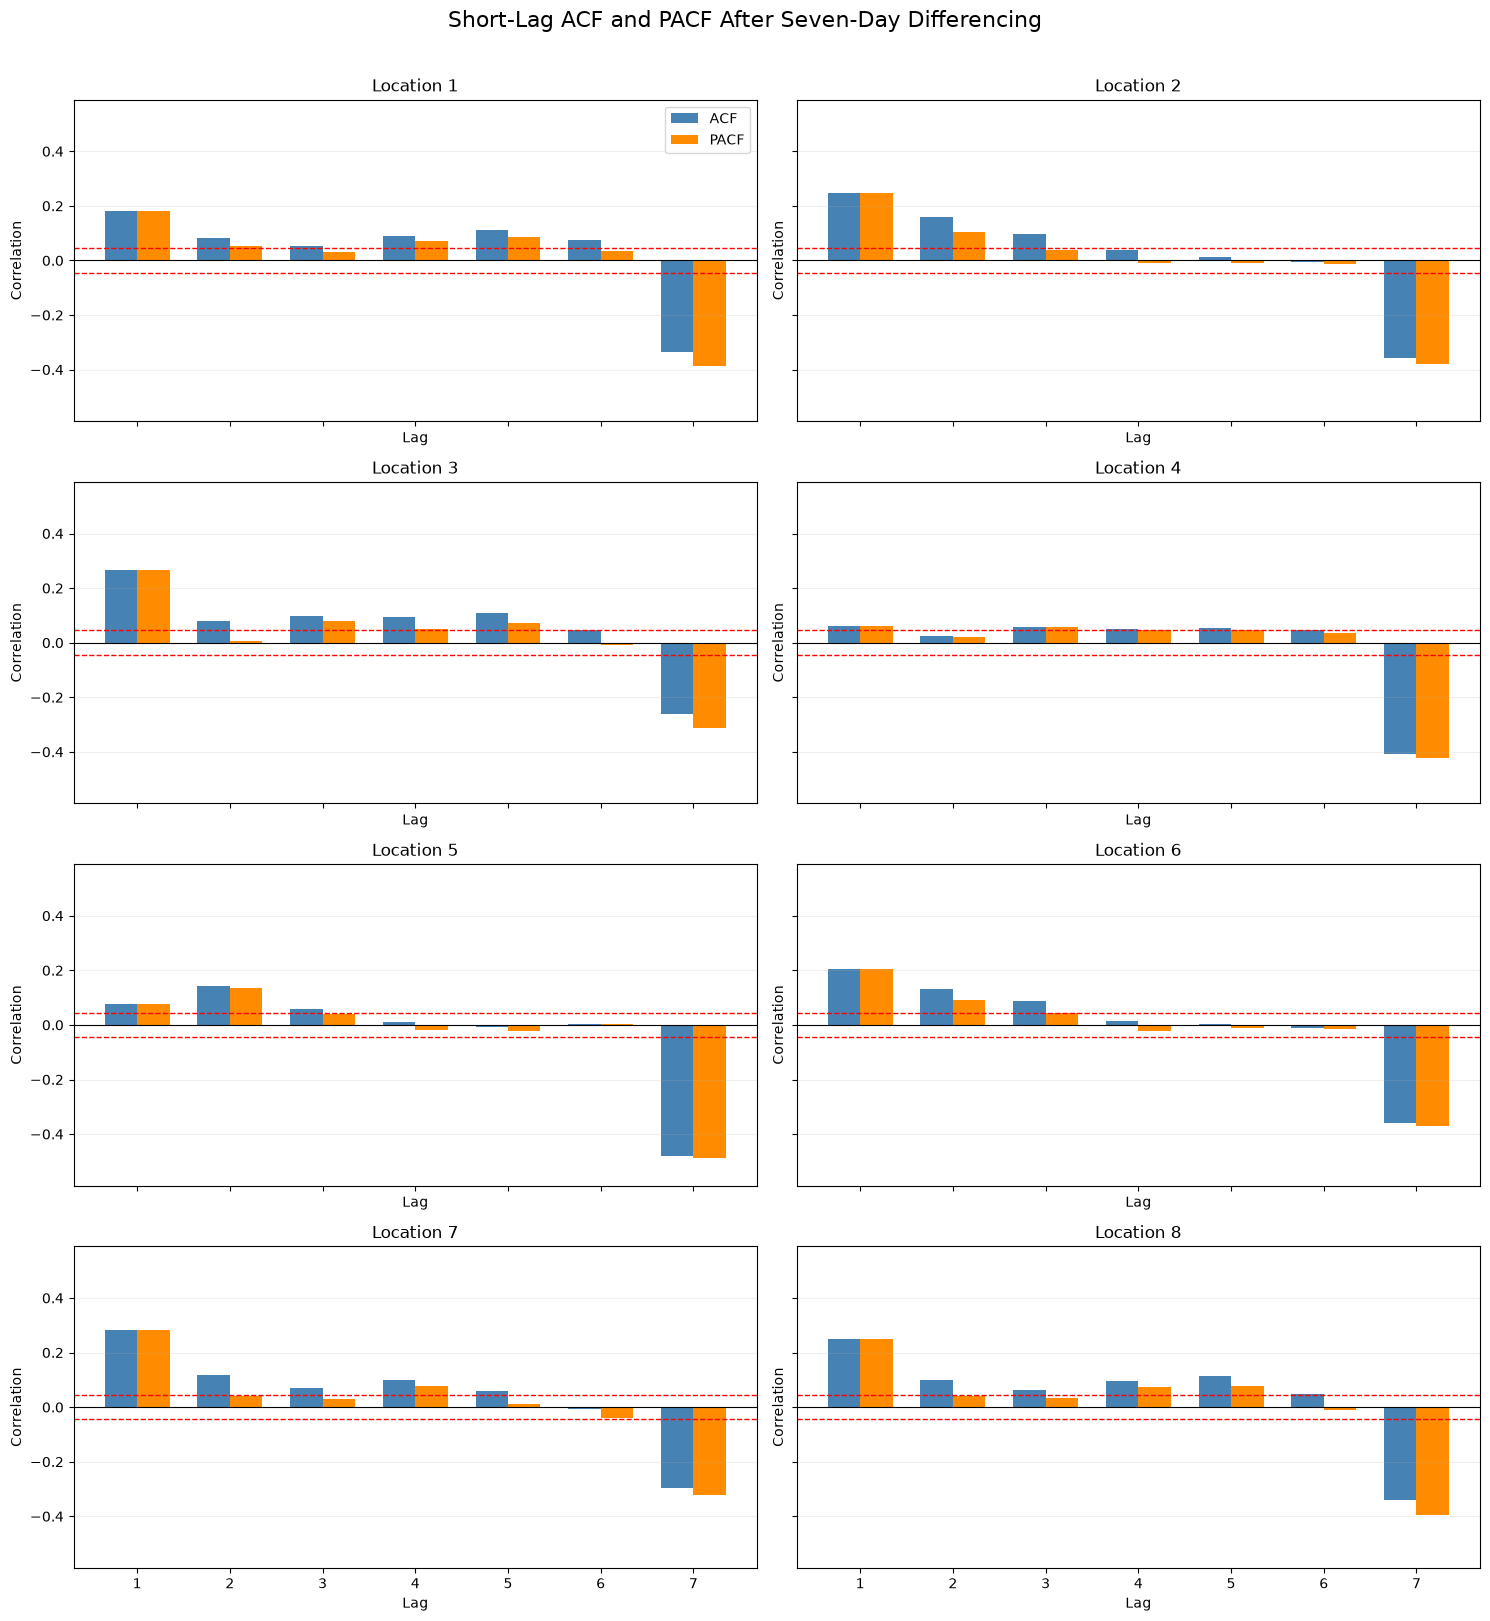

In [22]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(15, 16),
    sharex=True,
    sharey=True
)

axes = axes.flatten()
bar_width = 0.35

max_correlation = max(
    short_lag_table["acf"].abs().max(),
    short_lag_table["pacf"].abs().max(),
    short_lag_table["significance_limit"].max()
)

y_limit = min(1, max_correlation + 0.10)

for ax, (location, data) in zip(
    axes,
    short_lag_table.groupby("location")
):
    lags = data["lag"].to_numpy()
    significance = data["significance_limit"].iloc[0]

    ax.bar(
        lags - bar_width / 2,
        data["acf"],
        width=bar_width,
        color="steelblue",
        label="ACF"
    )

    ax.bar(
        lags + bar_width / 2,
        data["pacf"],
        width=bar_width,
        color="darkorange",
        label="PACF"
    )

    ax.axhline(
        significance,
        color="red",
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        -significance,
        color="red",
        linestyle="--",
        linewidth=1
    )

    ax.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    ax.set_title(f"Location {location}")
    ax.set_xticks(range(1, 8))
    ax.set_ylim(-y_limit, y_limit)
    ax.set_xlabel("Lag")
    ax.set_ylabel("Correlation")
    ax.grid(axis="y", alpha=0.2)

axes[0].legend()

fig.suptitle(
    "Short-Lag ACF and PACF After Seven-Day Differencing",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
save_chart(fig, "Short-Lag ACF and PACF After Seven-Day Differencing")
plt.show()

Every location has a large negative correlation at lag 7 after seasonal differencing
ACF ranges from approximately −0.26 to −0.48.
PACF ranges from approximately −0.31 to −0.49.
Combined with the earlier PACF negative spikes at 7, 14, 21, and 28, this supports a candidate seasonal MA term: (0,1,1,7)

Baseline will be established using a seasonal-naive forecast

In [23]:
train_df["weekday_num"] = train_df["Date"].dt.dayofweek
test_df["weekday_num"] = test_df["Date"].dt.dayofweek

In [24]:
#extracting the final week to be plotted with the forecast
last_training_week = (
    train_df.loc[
        train_df["Date"].between(
            TRAIN_END - pd.Timedelta(days=6),
            TRAIN_END
        ),
        ["location", "weekday_num", "model_volume"]
    ]
    .rename(
        columns={"model_volume": "seasonal_naive_forecast"}
    )
)

last_training_week

,location,weekday_num,seasonal_naive_forecast
1885,1,6,0.0
1886,1,0,2237.0
1887,1,1,2425.0
1888,1,2,2186.0
1889,1,3,2134.0
1890,1,4,2034.0
1891,1,5,0.0
3777,2,6,0.0
3778,2,0,503.0
3779,2,1,610.0


In [25]:
seasonal_naive_forecast = (
    test_df.merge(
        last_training_week,
        on=["location", "weekday_num"],
        how="left",
        validate="many_to_one"
    )
    .sort_values(["location", "Date"])
    .reset_index(drop=True)
)

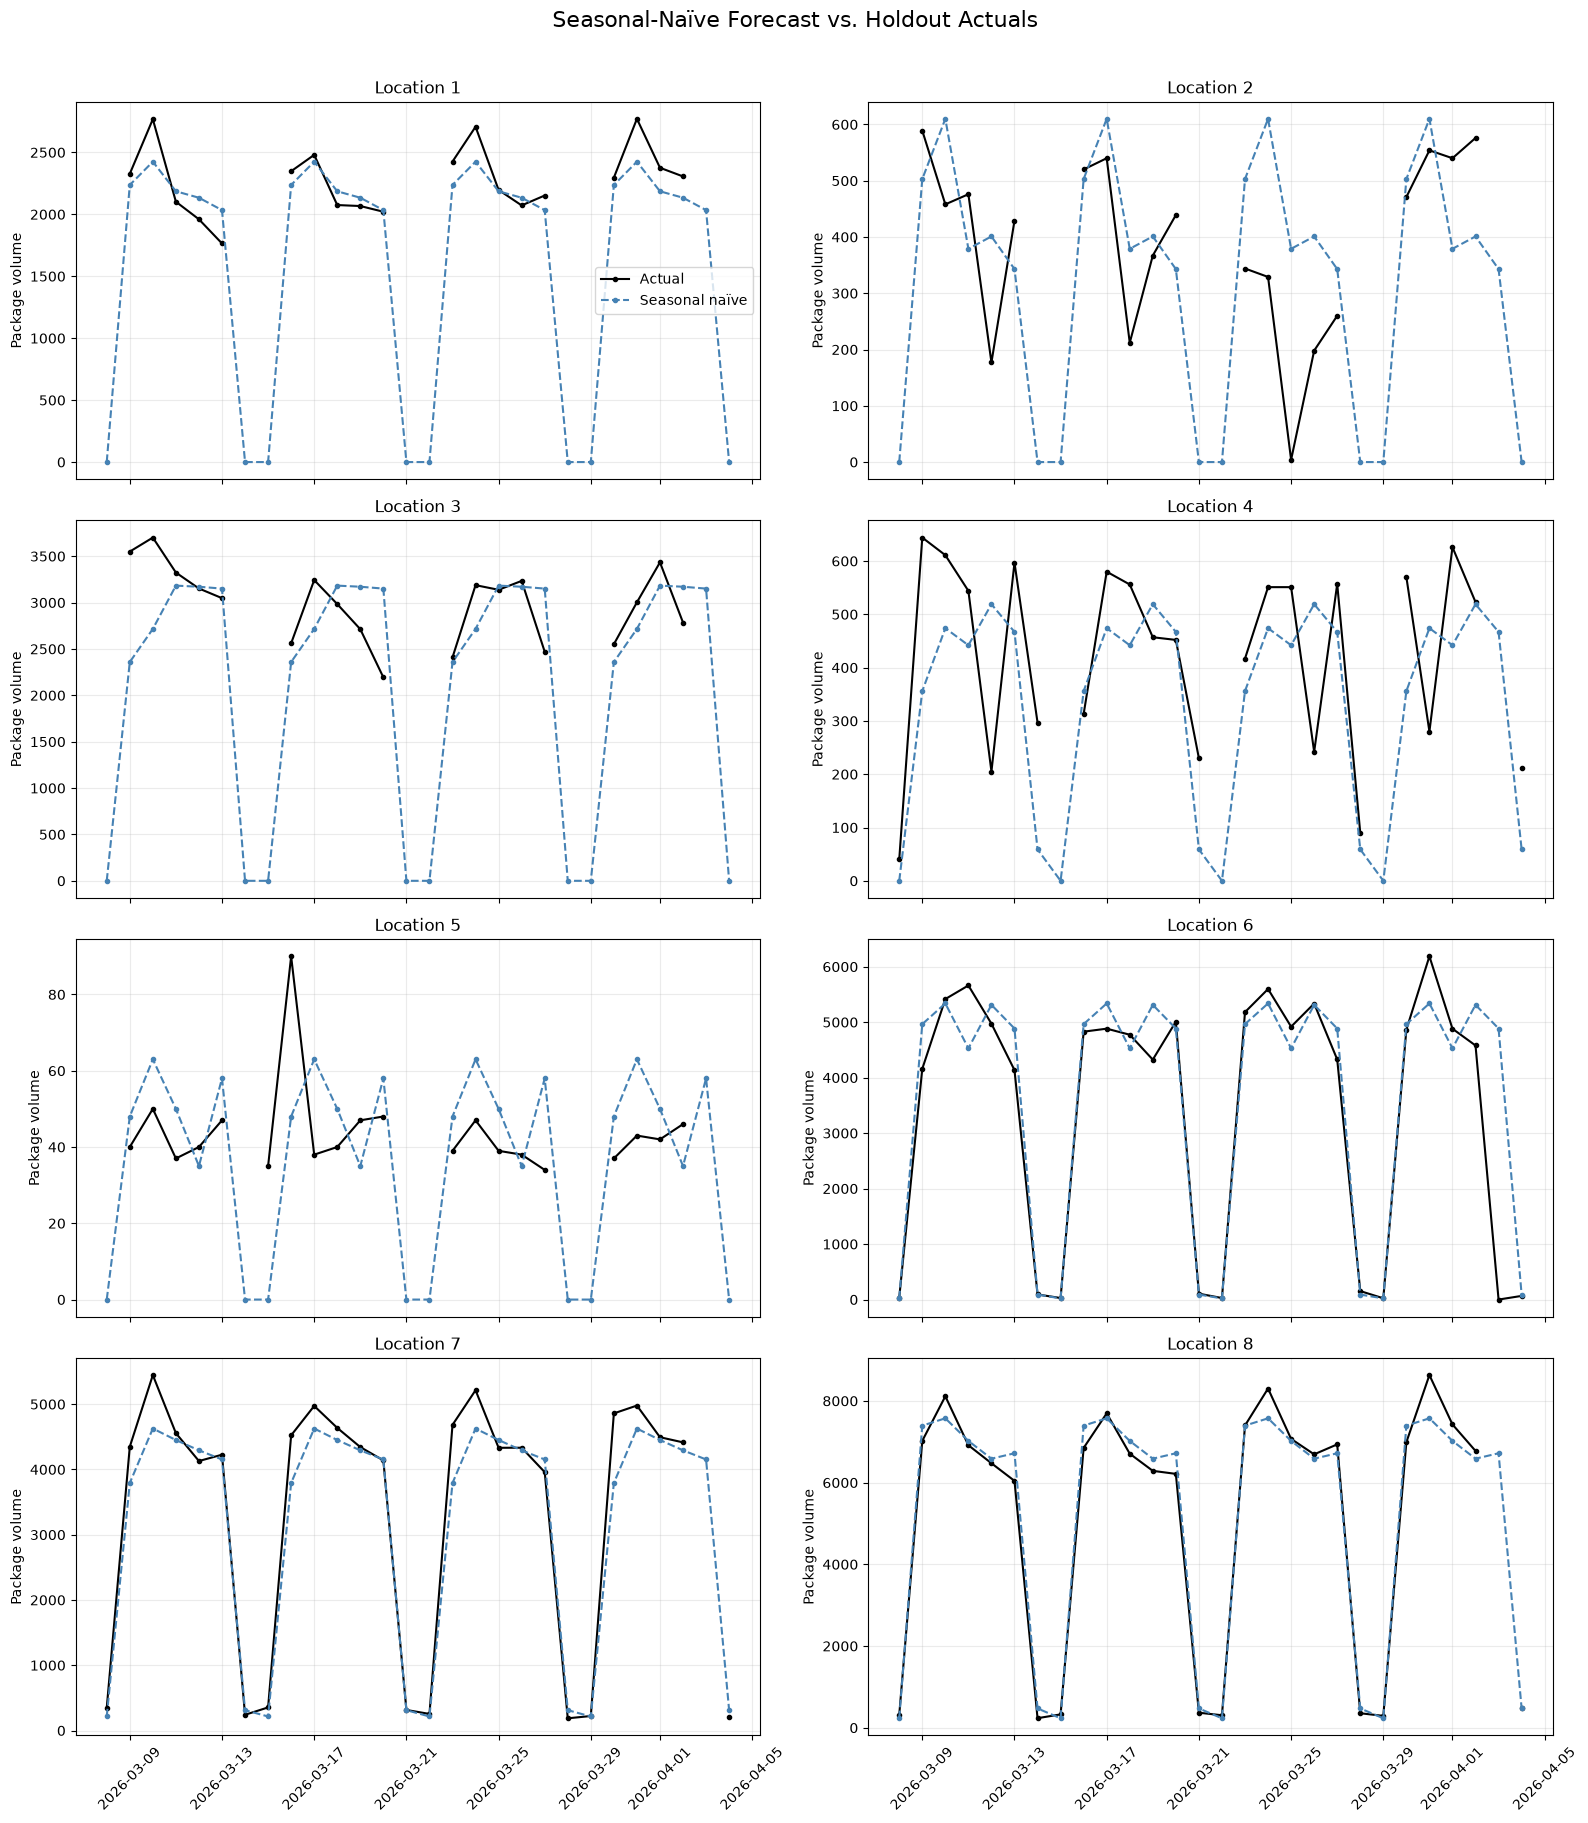

In [26]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(16, 18),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, (location, data) in zip(
    axes,
    seasonal_naive_forecast.groupby("location")
):
    data = data.sort_values("Date")

    ax.plot(
        data["Date"],
        data["actual"],
        color="black",
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Actual"
    )

    ax.plot(
        data["Date"],
        data["seasonal_naive_forecast"],
        color="steelblue",
        linestyle="--",
        marker="o",
        markersize=3,
        linewidth=1.5,
        label="Seasonal naïve"
    )

    ax.set_title(f"Location {location}")
    ax.set_ylabel("Package volume")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

axes[0].legend()

fig.suptitle(
    "Seasonal-Naïve Forecast vs. Holdout Actuals",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

In [27]:
#Evaluating the seasonal naive forecast
baseline_evaluation = seasonal_naive_forecast.loc[
    seasonal_naive_forecast["actual"].notna()
].copy()

baseline_evaluation["error"] = (
    baseline_evaluation["seasonal_naive_forecast"] -
    baseline_evaluation["actual"]
)

baseline_evaluation["absolute_error"] = (
    baseline_evaluation["error"].abs()
)

baseline_evaluation["squared_error"] = (
    baseline_evaluation["error"] ** 2
)

In [28]:
# calculating metrics by location
seasonal_naive_metrics = (
    baseline_evaluation.groupby("location")
    .apply(
        lambda data: pd.Series({
            "observations": len(data),
            "WAPE": (
                data["absolute_error"].sum() /
                data["actual"].sum()
            ),
            "MAE": data["absolute_error"].mean(),
            "RMSE": np.sqrt(
                data["squared_error"].mean()
            ),
            "Bias": (
                data["error"].sum() /
                data["actual"].sum()
            )
        }),
        include_groups=False
    )
    .reset_index()
)

seasonal_naive_metrics

,location,observations,WAPE,MAE,RMSE,Bias
0,1,19.0,0.063541,144.526316,176.185010,-0.027444
1,2,19.0,0.341307,134.421053,161.343374,0.149405
2,3,19.0,0.127183,379.421053,509.363535,-0.026693
3,4,24.0,0.310892,131.416667,157.226217,-0.132479
4,5,20.0,0.338655,14.850000,17.684739,0.092360
5,6,28.0,0.143359,484.214286,1030.638983,0.063294
6,7,27.0,0.079745,262.037037,396.955031,-0.062004
7,8,27.0,0.054849,278.740741,377.356497,0.000452


In [29]:
seasonal_naive_metrics.style.format({
    "WAPE": "{:.2%}",
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "Bias": "{:+.2%}"
})

,location,observations,WAPE,MAE,RMSE,Bias
0,1,19.000000,6.35%,145,176,-2.74%
1,2,19.000000,34.13%,134,161,+14.94%
2,3,19.000000,12.72%,379,509,-2.67%
3,4,24.000000,31.09%,131,157,-13.25%
4,5,20.000000,33.87%,15,18,+9.24%
5,6,28.000000,14.34%,484,"1,031",+6.33%
6,7,27.000000,7.97%,262,397,-6.20%
7,8,27.000000,5.48%,279,377,+0.05%


### Seasonal-naïve baseline
The seasonal-naïve forecast performed strongly for Locations 1, 7, and 8, but poorly for Locations 2, 4, and 5. Location 6 presents the greatest large-error risk, with RMSE exceeding 1,000 packages. These results establish the benchmark that more advanced models must improve upon.

#Testing the forecast on the data where the missing values were filled in using assumption.

In [30]:
imputed_evaluation = seasonal_naive_forecast.copy()

imputed_evaluation["evaluation_volume"] = (
    imputed_evaluation["model_volume"]
)

imputed_evaluation["error"] = (
    imputed_evaluation["seasonal_naive_forecast"] -
    imputed_evaluation["evaluation_volume"]
)

imputed_evaluation["absolute_error"] = (
    imputed_evaluation["error"].abs()
)

imputed_evaluation["squared_error"] = (
    imputed_evaluation["error"] ** 2
)

In [31]:
seasonal_naive_imputed_metrics = (
    imputed_evaluation.groupby("location")
    .apply(
        lambda data: pd.Series({
            "observations": len(data),
            "WAPE": (
                data["absolute_error"].sum() /
                data["evaluation_volume"].sum()
            ),
            "MAE": data["absolute_error"].mean(),
            "RMSE": np.sqrt(
                data["squared_error"].mean()
            ),
            "Bias": (
                data["error"].sum() /
                data["evaluation_volume"].sum()
            )
        }),
        include_groups=False
    )
    .reset_index()
)

seasonal_naive_imputed_metrics.style.format({
    "observations": "{:.0f}",
    "WAPE": "{:.2%}",
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "Bias": "{:+.2%}"
})

,location,observations,WAPE,MAE,RMSE,Bias
0,1,28,11.06%,171,411,+1.96%
1,2,28,38.71%,103,148,+19.52%
2,3,28,18.28%,370,728,+2.89%
3,4,28,35.69%,129,170,-8.64%
4,5,28,40.48%,13,19,+15.85%
5,6,28,14.34%,484,"1,031",+6.33%
6,7,28,12.66%,401,876,-1.52%
7,8,28,10.38%,509,"1,323",+4.94%


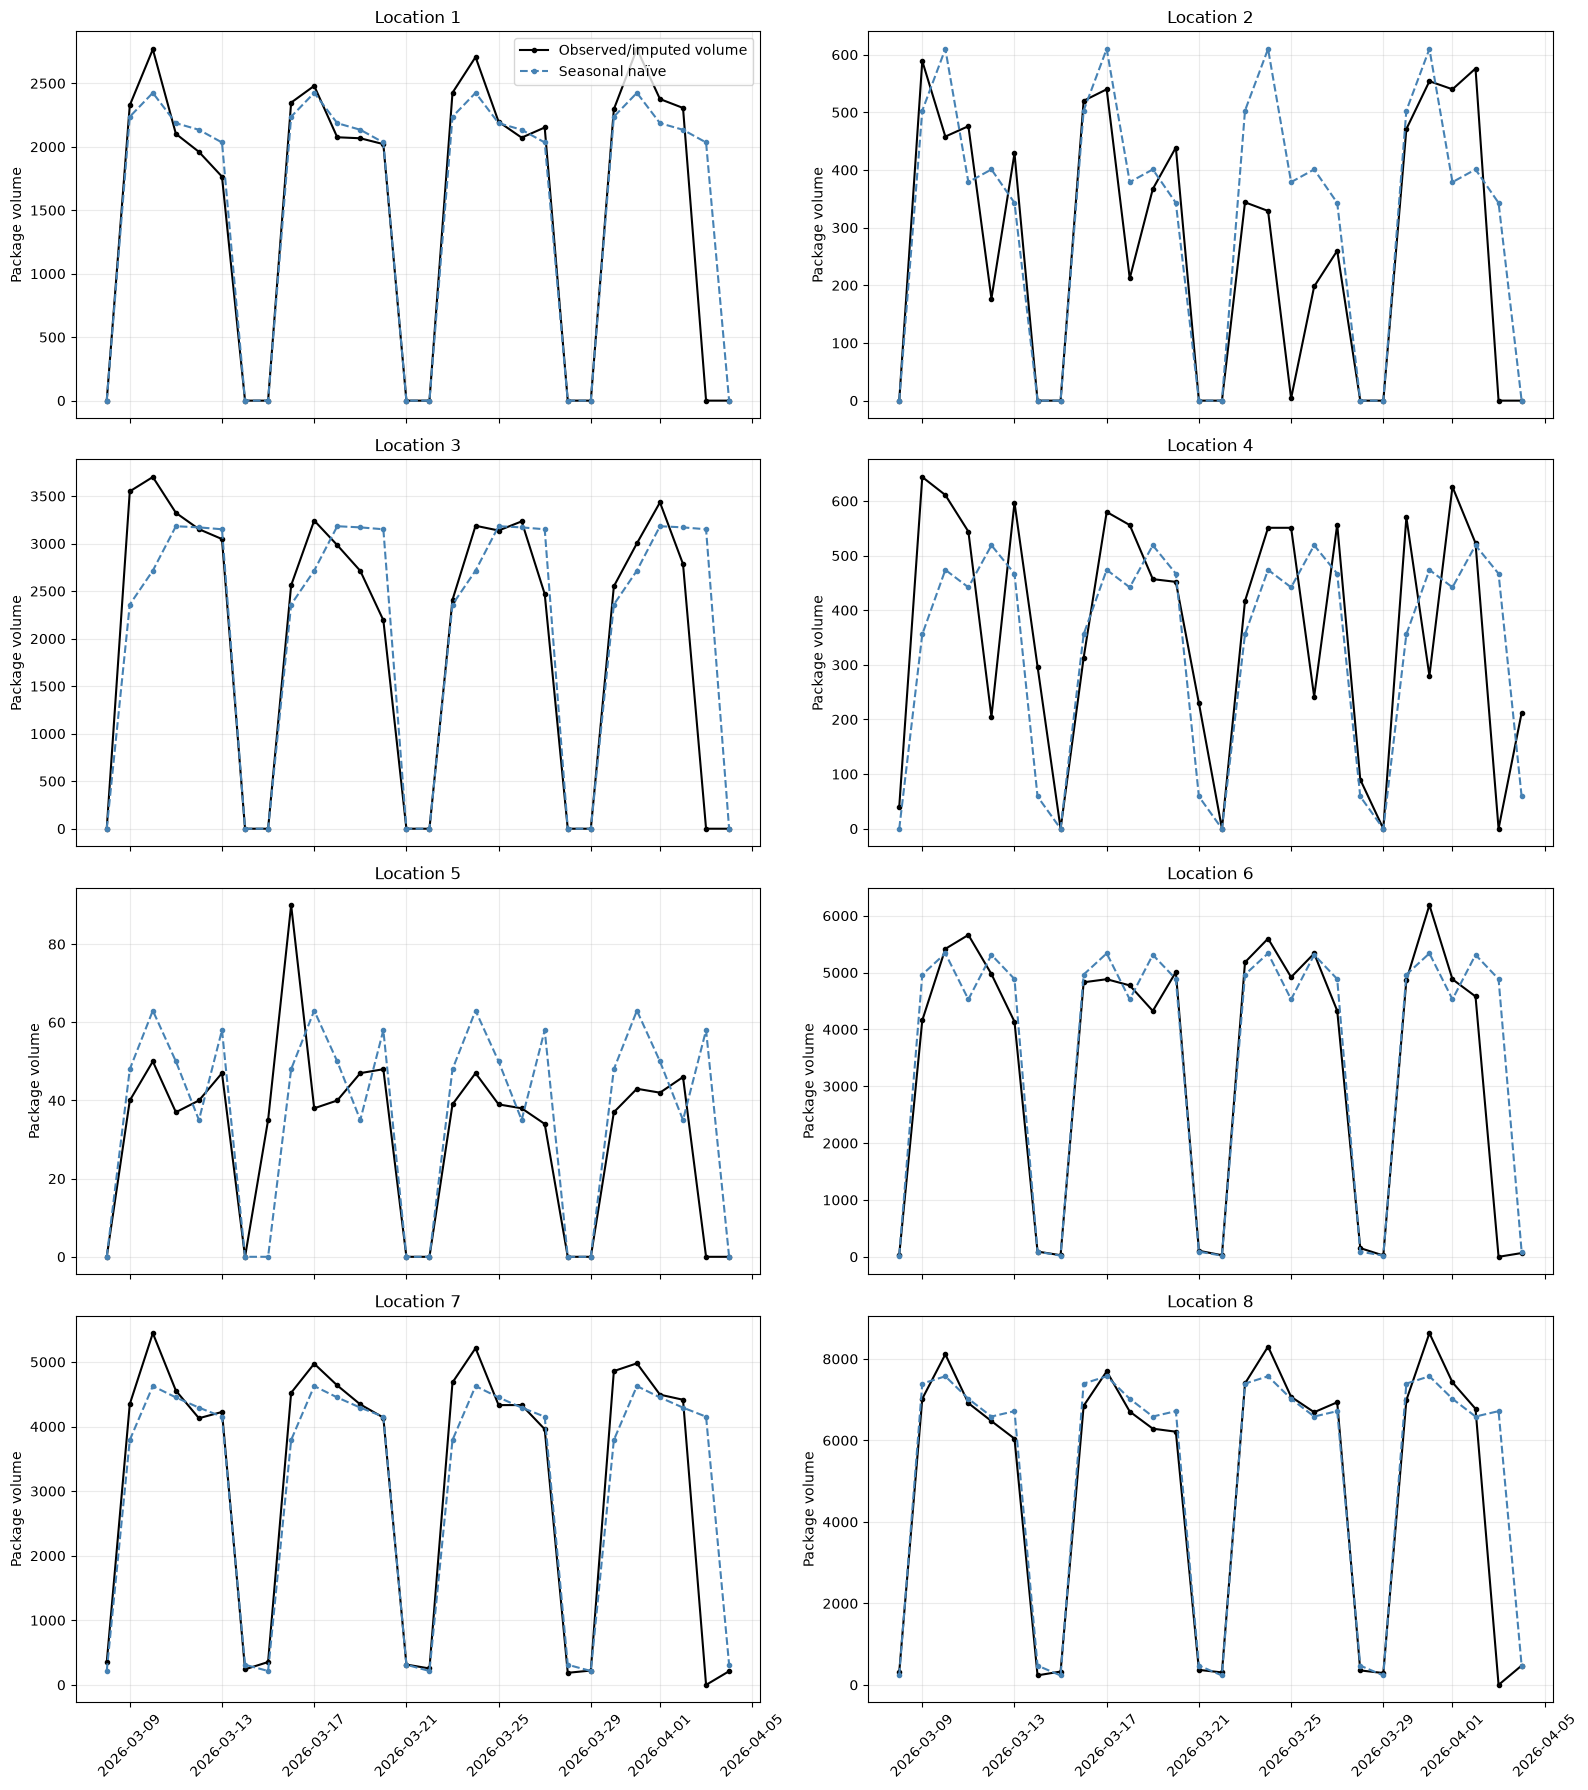

In [32]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(16, 18),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, (location, data) in zip(
    axes,
    imputed_evaluation.groupby("location")
):
    data = data.sort_values("Date")

    ax.plot(
        data["Date"],
        data["evaluation_volume"],
        color="black",
        marker="o",
        markersize=3,
        label="Observed/imputed volume"
    )

    ax.plot(
        data["Date"],
        data["seasonal_naive_forecast"],
        color="steelblue",
        linestyle="--",
        marker="o",
        markersize=3,
        label="Seasonal naïve"
    )

    ax.set_title(f"Location {location}")
    ax.set_ylabel("Package volume")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

axes[0].legend()
plt.tight_layout()
fig.savefig(
    "../outputs/figures/validation/seasonal_naive_comparison_by_location.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [33]:
#keeping the results measured against the imputed data
seasonal_naive_metrics = (
    seasonal_naive_imputed_metrics.copy()
)

In [34]:
#Creating a holiday dayfter and before flag to check if the model performs better
df_complete = (
    df_complete.sort_values(["location", "Date"])
    .reset_index(drop=True)
)

df_complete["holiday_flag"] = (
    df_complete["is_holiday"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["true", "1"])
    .astype("int8")
)

next_day_is_holiday = (
    df_complete.groupby("location")["holiday_flag"]
    .shift(-1)
    .fillna(0)
    .astype("int8")
)

previous_day_was_holiday = (
    df_complete.groupby("location")["holiday_flag"]
    .shift(1)
    .fillna(0)
    .astype("int8")
)

next_day_is_holiday = (
    df_complete.groupby("location")["holiday_flag"]
    .shift(-1)
    .fillna(0)
    .astype("int8")
)

previous_day_was_holiday = (
    df_complete.groupby("location")["holiday_flag"]
    .shift(1)
    .fillna(0)
    .astype("int8")
)


In [35]:
df_complete["day_before_holiday"] = (
    next_day_is_holiday.eq(1) &
    df_complete["holiday_flag"].eq(0)
).astype("int8")

df_complete["day_after_holiday"] = (
    previous_day_was_holiday.eq(1) &
    df_complete["holiday_flag"].eq(0)
).astype("int8")

In [36]:
train_df = df_complete.loc[
    df_complete["Date"].le(TRAIN_END)
].copy()

test_df = df_complete.loc[
    df_complete["Date"].between(
        TEST_START,
        TEST_END
    )
].copy()

In [37]:
#Fitting SARIMA to each location individually. 
SARIMA_ORDER = (1, 0, 1) # AR(1), no ordinary difference, MA(1)
SARIMA_SEASONAL_ORDER = (0, 1, 1, 7) # Seasonal difference and MA(1), weekly cycle
EXOG_COLUMNS = ["holiday_flag"]

sarimax_holiday_models = {}
sarimax_holiday_frames = []
sarimax_holiday_fit_summary = []

for location in sorted(train_df["location"].unique()):
    location_train = (
        train_df.loc[
            train_df["location"].eq(location)
        ]
        .sort_values("Date")
        .set_index("Date")
    )

    location_test = (
        test_df.loc[
            test_df["location"].eq(location)
        ]
        .sort_values("Date")
        .set_index("Date")
    )

    train_volume = (
        location_train["model_volume"]
        .astype(float)
        .asfreq("D")
    )

    train_exog = (
    location_train[EXOG_COLUMNS]
    .astype(float)
    .asfreq("D")
)

    test_exog = (
    location_test[EXOG_COLUMNS]
    .astype(float)
    .asfreq("D")
    )

    model = SARIMAX(
        endog=train_volume,
        exog=train_exog,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=200
    )

    sarimax_holiday_models[location] = fitted_model

    raw_forecast = fitted_model.get_forecast(
        steps=len(location_test),
        exog=test_exog
    ).predicted_mean.to_numpy()

    sarimax_holiday_frames.append(
        pd.DataFrame({
            "Date": location_test.index,
            "location": location,
            "sarimax_holiday_raw_forecast": raw_forecast,
            "sarimax_holiday_forecast": np.clip(
                raw_forecast,
                a_min=0,
                a_max=None
            )
        })
    )

    sarimax_holiday_fit_summary.append({
        "location": location,
        "AIC": fitted_model.aic,
        "BIC": fitted_model.bic,
        "holiday_coefficient": (
            fitted_model.params.get(
                "holiday_flag",
                np.nan
            )
        ),
        "converged": fitted_model.mle_retvals.get(
            "converged",
            False
        )
    })


In [38]:
sarimax_holiday_fit_summary = pd.DataFrame(
    sarimax_holiday_fit_summary
)

sarimax_holiday_fit_summary

,location,AIC,BIC,holiday_coefficient,converged
0,1,28094.835691,28122.520177,-2465.013397,True
1,2,24831.648605,24859.333091,-641.336863,True
2,3,28325.687407,28353.371892,-2598.340000,True
3,4,22798.422136,22826.106622,-418.657313,True
4,5,15743.062018,15770.746503,-31.818502,True
5,6,29648.253307,29675.937793,-4275.799395,True
6,7,30316.077865,30343.762351,-4871.441007,True
7,8,31813.832455,31841.516941,-6918.327476,True


In [39]:
sarimax_holiday_forecasts = pd.concat(
    sarimax_holiday_frames,
    ignore_index=True
)

sarimax_holiday_evaluation = (
    test_df[
        ["Date", "location", "model_volume"]
    ]
    .merge(
        sarimax_holiday_forecasts,
        on=["Date", "location"],
        how="left",
        validate="one_to_one"
    )
)

In [40]:
#calculating teh results of the SARIMA model
def calculate_metrics(
    data,
    forecast_column,
    actual_column="model_volume"
):
    results = []

    for location, location_data in data.groupby("location"):
        actual = location_data[actual_column].astype(float)
        forecast = location_data[forecast_column].astype(float)
        error = forecast - actual

        results.append({
            "location": location,
            "observations": len(location_data),
            "WAPE": (
                error.abs().sum() /
                actual.sum()
            ),
            "MAE": error.abs().mean(),
            "RMSE": np.sqrt(
                np.mean(error ** 2)
            ),
            "Bias": (
                error.sum() /
                actual.sum()
            )
        })

    return pd.DataFrame(results)

In [41]:
sarimax_holiday_metrics = calculate_metrics(
    sarimax_holiday_evaluation,
    "sarimax_holiday_forecast"
)

sarimax_holiday_metrics.style.format({
    "observations": "{:.0f}",
    "WAPE": "{:.2%}",
    "MAE": "{:,.0f}",
    "RMSE": "{:,.0f}",
    "Bias": "{:+.2%}"
})

,location,observations,WAPE,MAE,RMSE,Bias
0,1,28,6.10%,94,138,+3.91%
1,2,28,38.41%,103,167,+33.88%
2,3,28,10.50%,213,294,-1.42%
3,4,28,24.55%,89,122,-3.22%
4,5,28,49.88%,16,21,+35.01%
5,6,28,13.41%,453,595,+11.45%
6,7,28,7.24%,230,290,-0.74%
7,8,28,11.73%,575,696,+9.90%


In [42]:
#Comparing the seasonal naive model with SARIMA
model_comparison = (
    seasonal_naive_metrics.merge(
        sarimax_holiday_metrics,
        on="location",
        suffixes=(
            "_seasonal_naive",
            "_holiday_sarima"
        )
    )
)

model_comparison["WAPE_improvement"] = (
    model_comparison["WAPE_seasonal_naive"] -
    model_comparison["WAPE_holiday_sarima"]
)

model_comparison[
    [
        "location",
        "WAPE_seasonal_naive",
        "WAPE_holiday_sarima",
        "WAPE_improvement",
        "MAE_seasonal_naive",
        "MAE_holiday_sarima",
        "RMSE_seasonal_naive",
        "RMSE_holiday_sarima",
        "Bias_seasonal_naive",
        "Bias_holiday_sarima"
    ]
].style.format({
    "WAPE_seasonal_naive": "{:.2%}",
    "WAPE_holiday_sarima": "{:.2%}",
    "WAPE_improvement": "{:+.2%}",
    "MAE_seasonal_naive": "{:,.0f}",
    "MAE_holiday_sarima": "{:,.0f}",
    "RMSE_seasonal_naive": "{:,.0f}",
    "RMSE_holiday_sarima": "{:,.0f}",
    "Bias_seasonal_naive": "{:+.2%}",
    "Bias_holiday_sarima": "{:+.2%}"
})

,location,WAPE_seasonal_naive,WAPE_holiday_sarima,WAPE_improvement,MAE_seasonal_naive,MAE_holiday_sarima,RMSE_seasonal_naive,RMSE_holiday_sarima,Bias_seasonal_naive,Bias_holiday_sarima
0,1,11.06%,6.10%,+4.96%,171,94,411,138,+1.96%,+3.91%
1,2,38.71%,38.41%,+0.31%,103,103,148,167,+19.52%,+33.88%
2,3,18.28%,10.50%,+7.78%,370,213,728,294,+2.89%,-1.42%
3,4,35.69%,24.55%,+11.14%,129,89,170,122,-8.64%,-3.22%
4,5,40.48%,49.88%,-9.40%,13,16,19,21,+15.85%,+35.01%
5,6,14.34%,13.41%,+0.92%,484,453,"1,031",595,+6.33%,+11.45%
6,7,12.66%,7.24%,+5.41%,401,230,876,290,-1.52%,-0.74%
7,8,10.38%,11.73%,-1.35%,509,575,"1,323",696,+4.94%,+9.90%


In [43]:
#plotting the data
holiday_plot_data = (
    sarimax_holiday_evaluation.merge(
        seasonal_naive_forecast[
            [
                "Date",
                "location",
                "seasonal_naive_forecast"
            ]
        ],
        on=["Date", "location"],
        how="left",
        validate="one_to_one"
    )
    .merge(
        test_df[
            [
                "Date",
                "location",
                "is_holiday"
            ]
        ],
        on=["Date", "location"],
        how="left",
        validate="one_to_one"
    )
)

holiday_plot_data["is_holiday"] = (
    holiday_plot_data["is_holiday"]
    .astype(str)
    .str.lower()
    .eq("true")
)

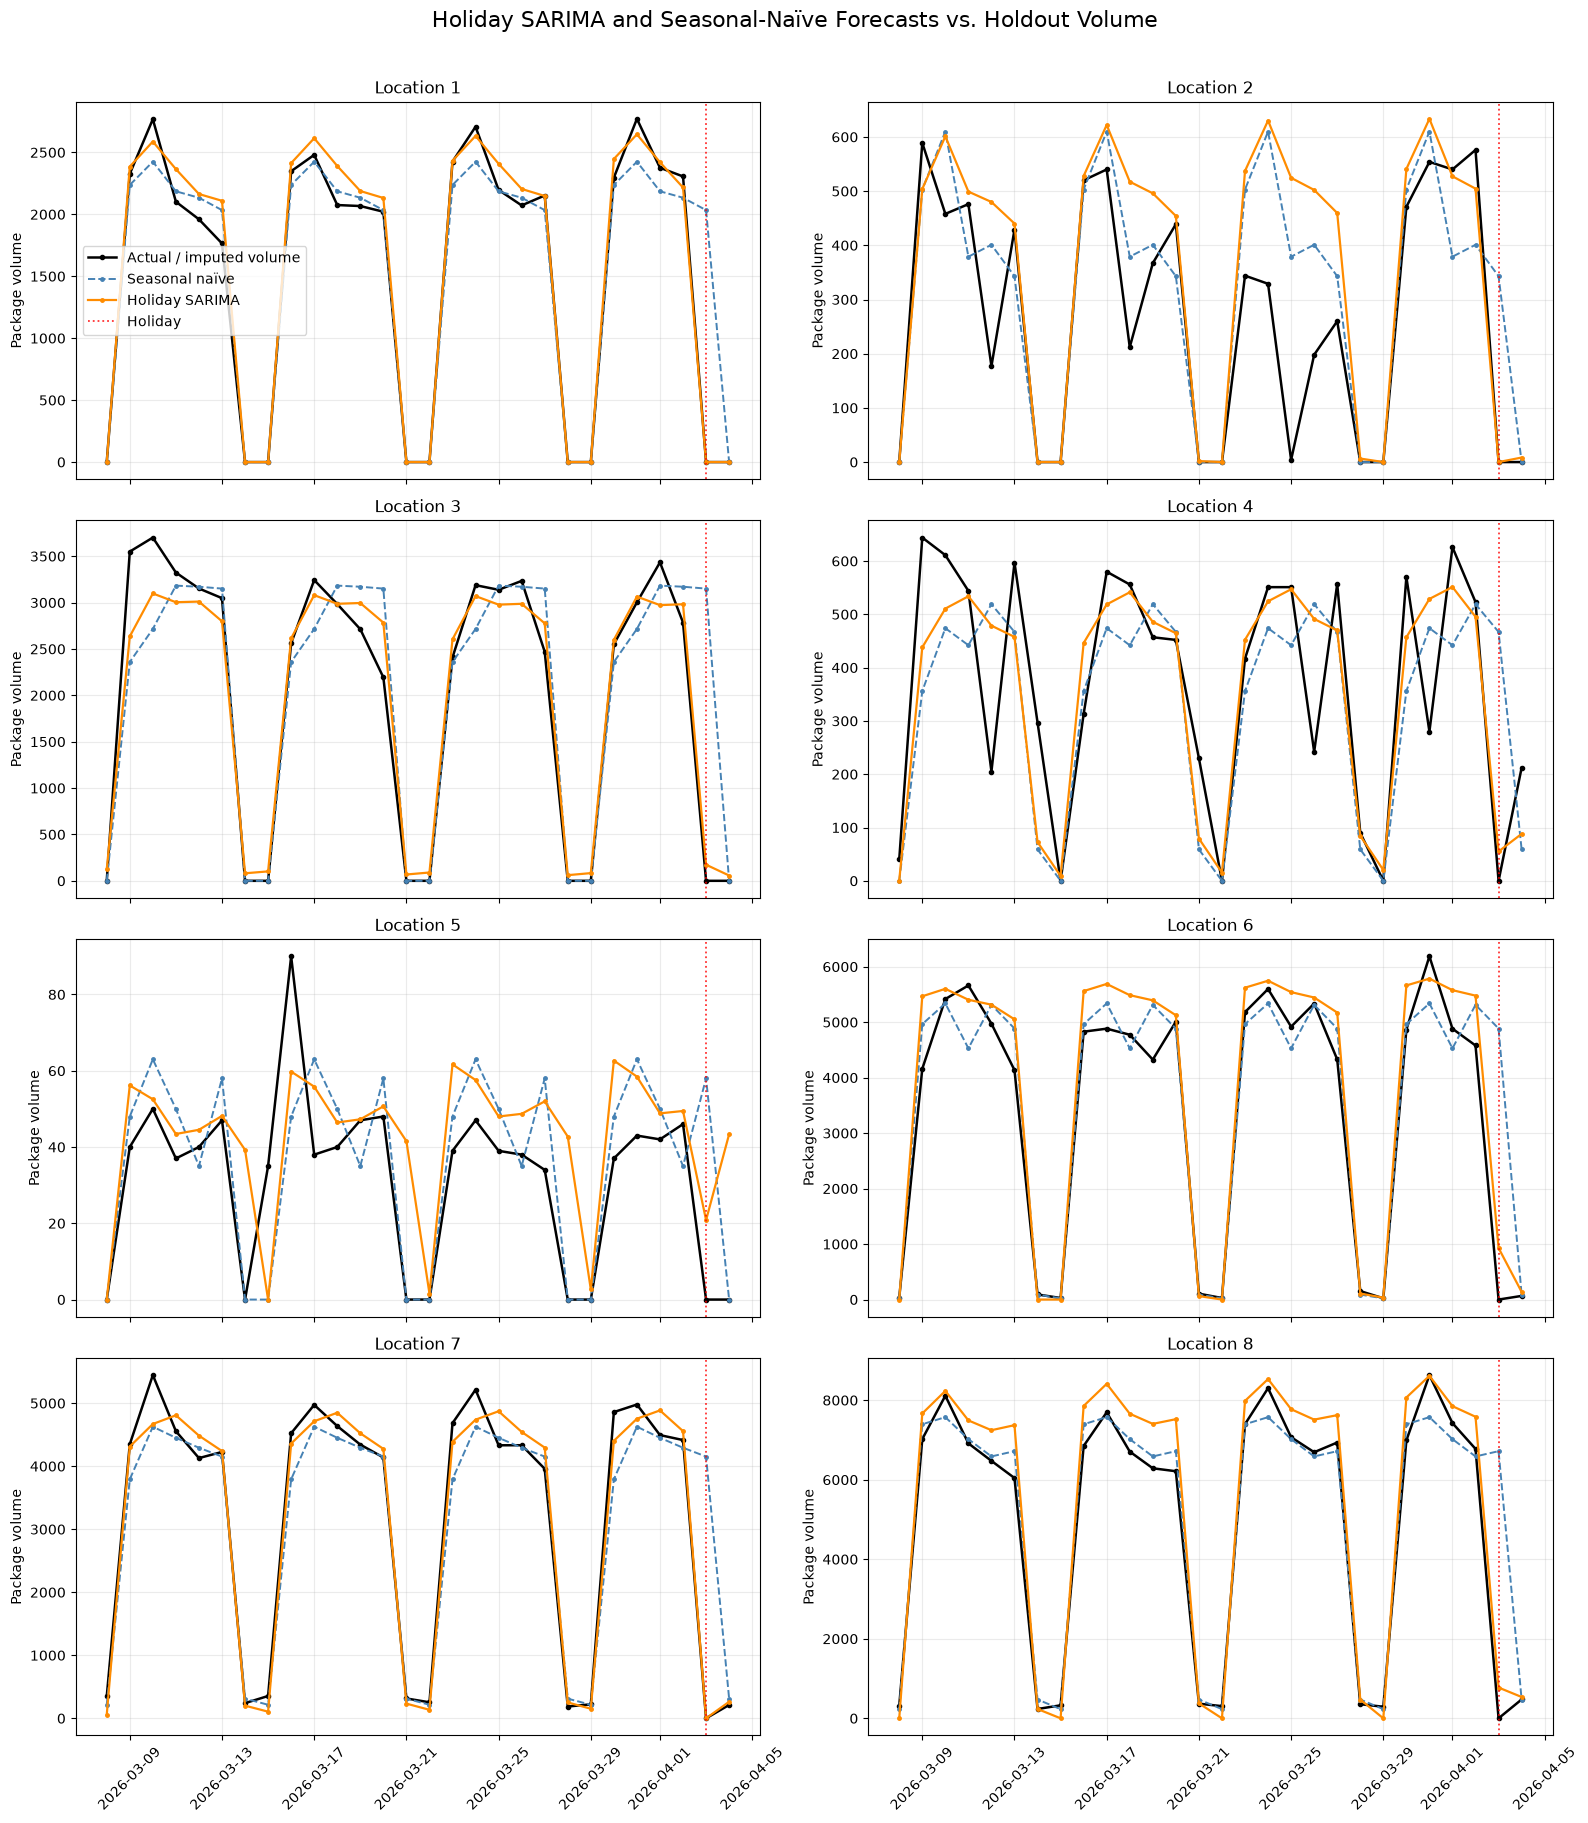

In [44]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(16, 18),
    sharex=True,
    sharey=False
)

axes = axes.flatten()

for ax, (location, data) in zip(
    axes,
    holiday_plot_data.groupby("location")
):
    data = data.sort_values("Date")

    ax.plot(
        data["Date"],
        data["model_volume"],
        color="black",
        marker="o",
        markersize=3,
        linewidth=1.8,
        label="Actual / imputed volume"
    )

    ax.plot(
        data["Date"],
        data["seasonal_naive_forecast"],
        color="steelblue",
        linestyle="--",
        marker="o",
        markersize=2.5,
        linewidth=1.4,
        label="Seasonal naïve"
    )

    ax.plot(
        data["Date"],
        data["sarimax_holiday_forecast"],
        color="darkorange",
        marker="o",
        markersize=2.5,
        linewidth=1.6,
        label="Holiday SARIMA"
    )

    holiday_dates = data.loc[
        data["is_holiday"],
        "Date"
    ]

    for index, holiday_date in enumerate(holiday_dates):
        ax.axvline(
            holiday_date,
            color="red",
            linestyle=":",
            linewidth=1.3,
            alpha=0.8,
            label="Holiday" if index == 0 else None
        )

    ax.set_title(f"Location {location}")
    ax.set_ylabel("Package volume")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

axes[0].legend()

fig.suptitle(
    "Holiday SARIMA and Seasonal-Naïve Forecasts vs. Holdout Volume",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
fig.savefig(
    "../outputs/figures/validation/SARIMA_Snaive_comparison_by_location.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [45]:
benchmark_forecasts = (
    test_df[
        ["Date", "location", "model_volume"]
    ]
    .merge(
        seasonal_naive_forecast[
            [
                "Date",
                "location",
                "seasonal_naive_forecast"
            ]
        ],
        on=["Date", "location"],
        how="left"
    )
    .merge(
        sarimax_holiday_forecasts[
            [
                "Date",
                "location",
                "sarimax_holiday_forecast"
            ]
        ],
        on=["Date", "location"],
        how="left"
    )
)

benchmark_forecasts.to_csv(
    "../outputs/tables/benchmark_holdout_forecasts.csv",
    index=False,
    date_format="%Y-%m-%d"
)

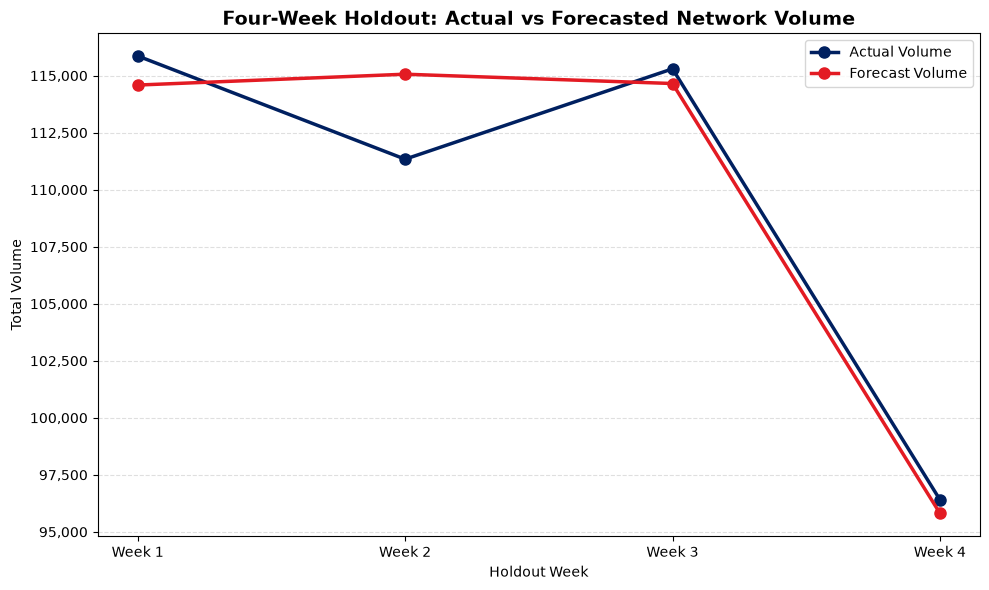

,forecast_week,actual_volume,forecast_volume
0,1,115862.0,114586.788543
1,2,111337.0,115062.754454
2,3,115298.0,114653.821426
3,4,96412.0,95818.811261


In [48]:
best_model_daily_forecasts = pd.read_csv(
   "../outputs/forecasts/best_model_daily_forecasts.csv",
    parse_dates=["Date"]
)
FIGURE_DIR = Path("../outputs/figures/forecast")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

holdout_weekly = best_model_daily_forecasts.copy()

holdout_weekly["Date"] = pd.to_datetime(holdout_weekly["Date"])

# Creates Week 1–4 based on consecutive seven-day forecast blocks
holdout_start = holdout_weekly["Date"].min()

holdout_weekly["forecast_week"] = (
    (holdout_weekly["Date"] - holdout_start).dt.days // 7 + 1
)

holdout_weekly_summary = (
    holdout_weekly
    .groupby("forecast_week", as_index=False)
    .agg(
        actual_volume=("actual_volume", "sum"),
        forecast_volume=("best_forecast", "sum")
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    holdout_weekly_summary["forecast_week"],
    holdout_weekly_summary["actual_volume"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#002060",
    label="Actual Volume"
)

ax.plot(
    holdout_weekly_summary["forecast_week"],
    holdout_weekly_summary["forecast_volume"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#E31B23",
    label="Forecast Volume"
)

ax.set_title(
    "Four-Week Holdout: Actual vs Forecasted Network Volume",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Holdout Week")
ax.set_ylabel("Total Volume")
ax.set_xticks(holdout_weekly_summary["forecast_week"])
ax.set_xticklabels(
    [f"Week {week}" for week in holdout_weekly_summary["forecast_week"]]
)
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:,.0f}")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "holdout_actual_vs_forecast_by_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "holdout_actual_vs_forecast_by_week.png", dpi=300, bbox_inches="tight")
plt.show()

holdout_weekly_summary